# Notebook 04 — Feature Engineering
## IndabaX Cameroon 2026 — Prédiction de la qualité de l'air

**Objectif** : Transformer le dataset brut `Base_complete.xlsx` en un dataset enrichi de features pertinentes pour la prédiction des 6 polluants + AQI global sur 42 villes camerounaises.

**Structure** :
- Section 0 : Imports, configuration, chargement
- Section 1 : Features temporelles
- Section 2 : Features météorologiques dérivées
- Section 3 : Features de lag (décalées)
- Section 4 : Features de fenêtre glissante (rolling)
- Section 5 : Features géographiques et climatiques
- Section 6 : Features d'interaction et non-linéaires
- Section 7 : Analyse qualité et sélection préliminaire
- Section 8 : Sauvegarde et rapport de synthèse

---
## Section 0 — Imports, configuration, chargement

In [1]:
# ── 0.1  Imports ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
import logging
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


In [2]:
# ── 0.2  Logger ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger(__name__)

# ── 0.3  Répertoires ─────────────────────────────────────────────────────────
ROOT   = pathlib.Path('..').resolve()
DATA   = ROOT / 'data'
MODELS = ROOT / 'models'
DATA.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

log.info('Répertoires : data=%s | models=%s', DATA, MODELS)

20:34:21 [INFO] Répertoires : data=C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data | models=C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\models


In [3]:
# ── 0.4  Chargement avec checkpoint ─────────────────────────────────────────
CKPT_RAW = DATA / 'base_complete.parquet'

if CKPT_RAW.exists():
    log.info('[SKIP] Checkpoint trouvé : chargement de %s', CKPT_RAW)
    df = pd.read_parquet(CKPT_RAW)
else:
    log.info('Lecture de Base_complete.xlsx …')
    df = pd.read_excel(DATA / 'Base_complete.xlsx')
    # Normalisation de la colonne temporelle
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values(['city_indabax', 'time']).reset_index(drop=True)
    df.to_parquet(CKPT_RAW, index=False)
    log.info('Sauvegardé → %s', CKPT_RAW)

log.info('Dataset chargé : %d lignes × %d colonnes', *df.shape)

20:34:21 [INFO] [SKIP] Checkpoint trouvé : chargement de C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\base_complete.parquet
20:34:21 [INFO] Dataset chargé : 87240 lignes × 32 colonnes


In [4]:
# ── 0.5  Aperçu rapide ───────────────────────────────────────────────────────
TARGETS = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2', 'aqi_global']

print('=== Shape :', df.shape)
print('\n=== Plage de dates :', df['time'].min().date(), '→', df['time'].max().date())
print('=== Nb villes      :', df['city_indabax'].nunique())
print('=== Nb régions     :', df['region_indabax'].nunique())
print('=== Valeurs manquantes totales :', df.isnull().sum().sum())
print('\n=== Types :')
print(df.dtypes)
print('\n=== Statistiques des cibles :')
df[TARGETS].describe().round(2)

=== Shape : (87240, 32)

=== Plage de dates : 2020-01-01 → 2025-12-20
=== Nb villes      : 40
=== Nb régions     : 10
=== Valeurs manquantes totales : 0

=== Types :
code                                   object
id                                      int64
time                           datetime64[ns]
weather_code                            int64
temperature_2m_max                    float64
temperature_2m_min                    float64
temperature_2m_mean                   float64
apparent_temperature_max              float64
apparent_temperature_min              float64
apparent_temperature_mean             float64
daylight_duration                     float64
sunshine_duration                     float64
precipitation_sum                     float64
rain_sum                              float64
snowfall_sum                            int64
precipitation_hours                     int64
wind_speed_10m_max                    float64
wind_gusts_10m_max                    float64
wind_d

,pm2_5,pm10,no2,o3,co,so2,aqi_global
count,87240.0000,87240.0000,87240.0000,87240.0000,87240.0000,87240.0000,87240.0000
mean,29.6700,45.4500,5.1600,62.8600,399.6200,2.3500,85.3800
std,30.9500,47.1600,5.6900,24.9100,340.1000,5.4000,45.9900
min,0.5000,0.7200,0.0000,8.8700,59.6200,0.0000,11.0000
25%,12.0800,17.9600,1.4100,45.1800,248.9100,0.4000,57.0000
50%,20.1400,31.1700,3.6700,57.7400,320.2500,0.9000,72.0000
75%,35.2000,54.7800,6.9000,76.8700,446.4300,1.9700,100.0000
max,972.3500,1344.9500,176.0300,283.8800,17178.6200,57.2500,500.0000


In [5]:
# ── 0.6  Trier correctement (crucial pour les lags) ──────────────────────────
df = df.sort_values(['city_indabax', 'time']).reset_index(drop=True)

# Dictionnaire pour le rapport final
feature_summary = {}

print('Tri par (city_indabax, time) — OK')

Tri par (city_indabax, time) — OK


---
## Section 1 — Features temporelles

In [6]:
# ── 1.1  Features calendaires de base ───────────────────────────────────────
log.info('Section 1 : Features temporelles…')

df['year']         = df['time'].dt.year
df['month']        = df['time'].dt.month
df['day_of_year']  = df['time'].dt.day_of_year          # 1–366
df['week_of_year'] = df['time'].dt.isocalendar().week.astype(int)  # 1–53
df['day_of_month'] = df['time'].dt.day
df['quarter']      = df['time'].dt.quarter

cal_features = ['year', 'month', 'day_of_year', 'week_of_year', 'day_of_month', 'quarter']
feature_summary.update({f: {'category': 'temporal_calendar', 'description': 'Feature calendaire de base'} for f in cal_features})
log.info('1.1 Calendaire : %d features créées', len(cal_features))

20:34:22 [INFO] Section 1 : Features temporelles…
20:34:22 [INFO] 1.1 Calendaire : 6 features créées


In [7]:
# ── 1.2  Encodage cyclique ───────────────────────────────────────────────────
# Sine/cosine pour éviter la discontinuité décembre→janvier, jour365→jour1

df['month_sin']        = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']        = np.cos(2 * np.pi * df['month'] / 12)
df['day_of_year_sin']  = np.sin(2 * np.pi * df['day_of_year'] / 366)
df['day_of_year_cos']  = np.cos(2 * np.pi * df['day_of_year'] / 366)
df['week_sin']         = np.sin(2 * np.pi * df['week_of_year'] / 53)
df['week_cos']         = np.cos(2 * np.pi * df['week_of_year'] / 53)

cyclic_features = ['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'week_sin', 'week_cos']
feature_summary.update({f: {'category': 'temporal_cyclic', 'description': 'Encodage cyclique sin/cos'} for f in cyclic_features})
log.info('1.2 Encodage cyclique : %d features créées', len(cyclic_features))

20:34:22 [INFO] 1.2 Encodage cyclique : 6 features créées


In [8]:
# ── 1.3  Saisons camerounaises ───────────────────────────────────────────────
# Classification climatique sub-saharienne propre au Cameroun

def get_cameroon_season(month: int) -> str:
    """Retourne la saison camerounaise en fonction du mois."""
    if month in (11, 12, 1, 2):
        return 'seche'
    elif month in (3, 10):
        return 'transition'
    else:  # 4–9
        return 'humide'

df['season']       = df['month'].map(get_cameroon_season)
df['is_dry_season'] = (df['season'] == 'seche').astype(int)
df['is_wet_season'] = (df['season'] == 'humide').astype(int)
# Harmattan : vents chargés de poussières du Sahara, nov–fév → pics PM2.5/PM10
df['is_harmattan']  = df['is_dry_season'].copy()

season_features = ['season', 'is_dry_season', 'is_wet_season', 'is_harmattan']
feature_summary.update({
    'season':        {'category': 'temporal_season', 'description': 'Saison camerounaise (seche/transition/humide)'},
    'is_dry_season': {'category': 'temporal_season', 'description': 'Flag saison sèche (nov-fév)'},
    'is_wet_season': {'category': 'temporal_season', 'description': 'Flag saison humide (avr-sep)'},
    'is_harmattan':  {'category': 'temporal_season', 'description': 'Flag harmattan (nov-fév) : corrélé PM2.5/PM10'},
})

print('Distribution des saisons :')
print(df['season'].value_counts())
log.info('1.3 Saisons camerounaises : OK')

20:34:22 [INFO] 1.3 Saisons camerounaises : OK


Distribution des saisons :
season
humide        43920
seche         28440
transition    14880
Name: count, dtype: int64


In [9]:
# ── 1.4  Tendance temporelle linéaire ────────────────────────────────────────
df['days_since_start'] = (df['time'] - df['time'].min()).dt.days

feature_summary['days_since_start'] = {
    'category': 'temporal_trend',
    'description': 'Nb jours depuis le début de la série (dérive temporelle)'
}

log.info('1.4 Tendance linéaire : days_since_start 0→%d', df['days_since_start'].max())
print('\n=== Récapitulatif Section 1 ===')
print(f'Features temporelles créées : {len(cal_features) + len(cyclic_features) + len(season_features) + 1}')

20:34:22 [INFO] 1.4 Tendance linéaire : days_since_start 0→2180



=== Récapitulatif Section 1 ===
Features temporelles créées : 17


---
## Section 2 — Features météorologiques dérivées

In [10]:
# ── 2.1  Amplitude thermique ─────────────────────────────────────────────────
log.info('Section 2 : Features météorologiques dérivées…')

df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
# Forte amplitude → meilleure dispersion des polluants

feature_summary['temp_range'] = {
    'category': 'meteo_derived',
    'description': 'Amplitude thermique journalière (max-min)'
}
log.info('2.1 Amplitude thermique : OK')

20:34:22 [INFO] Section 2 : Features météorologiques dérivées…
20:34:22 [INFO] 2.1 Amplitude thermique : OK


In [11]:
# ── 2.2  Écart température ressentie vs réelle ───────────────────────────────
# Proxy de l'humidité + vent : écart négatif fort = vent fort ou faible humidité

df['apparent_temp_diff_max']  = df['apparent_temperature_max']  - df['temperature_2m_max']
df['apparent_temp_diff_mean'] = df['apparent_temperature_mean'] - df['temperature_2m_mean']

feature_summary.update({
    'apparent_temp_diff_max':  {'category': 'meteo_derived', 'description': 'Écart T ressentie max vs T réelle max'},
    'apparent_temp_diff_mean': {'category': 'meteo_derived', 'description': 'Écart T ressentie moy vs T réelle moy'},
})
log.info('2.2 Écart T ressentie : OK')

20:34:22 [INFO] 2.2 Écart T ressentie : OK


In [12]:
# ── 2.3  Fraction d'ensoleillement ───────────────────────────────────────────
# sunshine_fraction ∈ [0,1]. Proxy de nébulosité.
# O3 fortement corrélé à l'ensoleillement (photochimie).

df['sunshine_fraction'] = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)
# Clamp à [0,1] par sécurité (erreurs d'arrondi possibles)
df['sunshine_fraction'] = df['sunshine_fraction'].clip(0, 1)

feature_summary['sunshine_fraction'] = {
    'category': 'meteo_derived',
    'description': 'Fraction ensoleillement réel / durée du jour (proxy nébulosité)'
}
log.info('2.3 Fraction ensoleillement : OK')

20:34:22 [INFO] 2.3 Fraction ensoleillement : OK


In [13]:
# ── 2.4  Intensité de la précipitation ───────────────────────────────────────
# La pluie lessive les particules → PM2.5 et PM10 chutent après les pluies

df['precip_intensity'] = df['precipitation_sum'] / (df['precipitation_hours'] + 0.01)
df['precip_flag']      = (df['precipitation_sum'] > 0).astype(int)

feature_summary.update({
    'precip_intensity': {'category': 'meteo_derived', 'description': 'Intensité précipitation (mm/h effectif)'},
    'precip_flag':      {'category': 'meteo_derived', 'description': 'Flag : jour de pluie (0/1)'},
})
log.info('2.4 Précipitations : OK')

20:34:22 [INFO] 2.4 Précipitations : OK


In [14]:
# ── 2.5  Décomposition vectorielle du vent ───────────────────────────────────
# Évite la discontinuité à 0°/360° pour les modèles ML

wind_dir_rad = np.deg2rad(df['wind_direction_10m_dominant'])
df['wind_u'] = df['wind_speed_10m_max'] * np.sin(wind_dir_rad)  # composante E-W
df['wind_v'] = df['wind_speed_10m_max'] * np.cos(wind_dir_rad)  # composante N-S

# Vent calme → mauvaise dispersion → accumulation des polluants
df['calm_wind_flag'] = (df['wind_speed_10m_max'] < 2.0).astype(int)

feature_summary.update({
    'wind_u':        {'category': 'meteo_derived', 'description': 'Composante vent E-O (vectorielle)'},
    'wind_v':        {'category': 'meteo_derived', 'description': 'Composante vent N-S (vectorielle)'},
    'calm_wind_flag':{'category': 'meteo_derived', 'description': 'Flag vent calme (<2 m/s) : accumulation polluants'},
})
log.info('2.5 Vent vectoriel + flag calme : OK')

20:34:22 [INFO] 2.5 Vent vectoriel + flag calme : OK


In [15]:
# ── 2.6  Anomalie ET0 (proxy humidité relative) ───────────────────────────────
# Valeur positive → journée plus sèche que la moyenne du mois pour cette ville

et0_city_month_mean = (
    df.groupby(['city_indabax', 'month'])['et0_fao_evapotranspiration']
      .transform('mean')
)
df['et0_anomaly'] = df['et0_fao_evapotranspiration'] - et0_city_month_mean

feature_summary['et0_anomaly'] = {
    'category': 'meteo_derived',
    'description': 'Anomalie ET0 vs moyenne mois×ville (proxy sécheresse)'
}
log.info('2.6 Anomalie ET0 : OK')

20:34:22 [INFO] 2.6 Anomalie ET0 : OK


In [16]:
# ── 2.7  Rayonnement relatif ─────────────────────────────────────────────────
# MJ/m² par heure effective de jour → corrélé à la formation photochimique de O3

daylight_h = df['daylight_duration'] / 3600  # secondes → heures
df['radiation_per_daylight'] = df['shortwave_radiation_sum'] / (daylight_h + 1e-6)

feature_summary['radiation_per_daylight'] = {
    'category': 'meteo_derived',
    'description': 'Rayonnement court. relatif par heure de jour (MJ/m²/h)'
}

meteo_derived = [
    'temp_range', 'apparent_temp_diff_max', 'apparent_temp_diff_mean',
    'sunshine_fraction', 'precip_intensity', 'precip_flag',
    'wind_u', 'wind_v', 'calm_wind_flag', 'et0_anomaly', 'radiation_per_daylight'
]
log.info('Section 2 terminée : %d features météo dérivées', len(meteo_derived))

20:34:22 [INFO] Section 2 terminée : 11 features météo dérivées


---
## Section 3 — Features de lag (décalées) — CRITIQUE ANTI-LEAKAGE

> **Règle absolue** : `shift(n)` avec `n ≥ 1`, groupé par `city_indabax`, trié par `time`.  
> Jamais de `shift(0)` pour une feature de prédiction.

In [17]:
# ── 3.1  Lags des polluants ───────────────────────────────────────────────────
log.info('Section 3 : Features de lag…')

POLLUTANTS = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']
LAG_STEPS  = [1, 2, 3, 7, 14, 30]

lag_cols_created = []

for p in POLLUTANTS:
    for lag in LAG_STEPS:
        col = f'{p}_lag{lag}'
        # groupby city pour ne pas mélanger les séries des différentes villes
        df[col] = df.groupby('city_indabax')[p].transform(lambda s: s.shift(lag))
        lag_cols_created.append(col)
        feature_summary[col] = {
            'category': 'lag_pollutant',
            'description': f'Valeur de {p} à j-{lag} (persistence atmosphérique)'
        }

log.info('3.1 Lags polluants : %d features créées', len(lag_cols_created))

20:34:22 [INFO] Section 3 : Features de lag…
20:34:23 [INFO] 3.1 Lags polluants : 36 features créées


In [18]:
# ── 3.2  Lags de l'AQI global ────────────────────────────────────────────────

for lag in [1, 7]:
    col = f'aqi_global_lag{lag}'
    df[col] = df.groupby('city_indabax')['aqi_global'].transform(lambda s: s.shift(lag))
    lag_cols_created.append(col)
    feature_summary[col] = {
        'category': 'lag_aqi',
        'description': f'AQI global à j-{lag}'
    }

log.info('3.2 Lags AQI global : OK')

20:34:23 [INFO] 3.2 Lags AQI global : OK


In [19]:
# ── 3.3  Lags des variables météo clés ───────────────────────────────────────

meteo_lag_config = {
    'precipitation_sum':      [1, 3],   # effet lessivage décalé
    'wind_speed_10m_max':     [1],
    'temperature_2m_mean':    [1, 3],
}

for col_name, lags in meteo_lag_config.items():
    for lag in lags:
        new_col = f'{col_name}_lag{lag}'
        df[new_col] = df.groupby('city_indabax')[col_name].transform(lambda s, l=lag: s.shift(l))
        lag_cols_created.append(new_col)
        feature_summary[new_col] = {
            'category': 'lag_meteo',
            'description': f'{col_name} à j-{lag}'
        }

log.info('3.3 Lags météo : OK')

20:34:23 [INFO] 3.3 Lags météo : OK


In [20]:
# ── 3.4  Imputation des NaN créés par les lags ────────────────────────────────
# Les lags créent des NaN en début de série (30 premiers jours par ville max).
# On ne supprime pas ces lignes (cibles valides).
# Stratégie : médiane de la ville pour chaque feature de lag.

log.info('NaN avant imputation des lags : %d', df[lag_cols_created].isnull().sum().sum())

for col in lag_cols_created:
    city_medians = df.groupby('city_indabax')[col].transform('median')
    df[col] = df[col].fillna(city_medians)
    # Fallback global si une ville entière est NaN
    df[col] = df[col].fillna(df[col].median())
    feature_summary[col]['nan_after_imputation'] = int(df[col].isnull().sum())

remaining_nan = df[lag_cols_created].isnull().sum().sum()
log.info('NaN après imputation (médiane ville) : %d', remaining_nan)
print(f'Total features de lag créées : {len(lag_cols_created)}')

20:34:23 [INFO] NaN avant imputation des lags : 14360
20:34:24 [INFO] NaN après imputation (médiane ville) : 0


Total features de lag créées : 43


---
## Section 4 — Features de fenêtre glissante (rolling statistics)

> **Anti-leakage** : `shift(1)` avant `rolling()` pour exclure la valeur courante.

In [21]:
# ── Helpers rolling anti-leakage ────────────────────────────────────────────
log.info('Section 4 : Rolling statistics…')

def rolling_stat(series: pd.Series, window: int, stat: str = 'mean') -> pd.Series:
    """
    Calcule une statistique glissante SANS leakage :
    - shift(1) d'abord pour exclure la valeur courante
    - rolling(window) sur le passé uniquement
    min_periods = max(1, window//2) pour les débuts de série
    """
    shifted = series.shift(1)
    min_p   = max(1, window // 2)
    r = shifted.rolling(window=window, min_periods=min_p)
    if stat == 'mean':
        return r.mean()
    elif stat == 'std':
        return r.std()
    elif stat == 'max':
        return r.max()
    elif stat == 'sum':
        return r.sum()
    raise ValueError(f'Stat inconnue : {stat}')

print('Helper rolling_stat défini (shift(1) + rolling, anti-leakage)')

20:34:24 [INFO] Section 4 : Rolling statistics…


Helper rolling_stat défini (shift(1) + rolling, anti-leakage)


In [22]:
# ── 4.1  Rolling mean des polluants ──────────────────────────────────────────
rolling_cols_created = []

WINDOWS_MEAN = [7, 14, 30]

for p in POLLUTANTS:
    for w in WINDOWS_MEAN:
        col = f'{p}_roll{w}_mean'
        df[col] = df.groupby('city_indabax')[p].transform(
            lambda s, ww=w: rolling_stat(s, ww, 'mean')
        )
        rolling_cols_created.append(col)
        feature_summary[col] = {
            'category': 'rolling_mean',
            'description': f'Moyenne glissante {p} sur {w}j (anti-leakage)'
        }

log.info('4.1 Rolling mean : %d features', len(rolling_cols_created))

20:34:24 [INFO] 4.1 Rolling mean : 18 features


In [23]:
# ── 4.2  Rolling std ─────────────────────────────────────────────────────────
std_cols = []
for p in POLLUTANTS:
    col = f'{p}_roll7_std'
    df[col] = df.groupby('city_indabax')[p].transform(
        lambda s: rolling_stat(s, 7, 'std')
    )
    std_cols.append(col)
    feature_summary[col] = {
        'category': 'rolling_std',
        'description': f'Écart-type glissant {p} sur 7j (volatilité locale)'
    }
rolling_cols_created.extend(std_cols)
log.info('4.2 Rolling std : %d features', len(std_cols))

20:34:24 [INFO] 4.2 Rolling std : 6 features


In [24]:
# ── 4.3  Rolling max (pics récents) ──────────────────────────────────────────
max_cols = []
for p in POLLUTANTS:
    col = f'{p}_roll7_max'
    df[col] = df.groupby('city_indabax')[p].transform(
        lambda s: rolling_stat(s, 7, 'max')
    )
    max_cols.append(col)
    feature_summary[col] = {
        'category': 'rolling_max',
        'description': f'Max glissant {p} sur 7j (pics récents)'
    }
rolling_cols_created.extend(max_cols)
log.info('4.3 Rolling max : %d features', len(max_cols))

20:34:25 [INFO] 4.3 Rolling max : 6 features


In [25]:
# ── 4.4  Rolling météo ───────────────────────────────────────────────────────
meteo_roll_config = {
    'precipitation_sum':     ('sum',  7),
    'temperature_2m_mean':   ('mean', 7),
    'wind_speed_10m_max':    ('mean', 7),
    'sunshine_fraction':     ('mean', 7),
}

meteo_roll_cols = []
for col_name, (stat, w) in meteo_roll_config.items():
    new_col = f'{col_name}_roll{w}_{stat}'
    df[new_col] = df.groupby('city_indabax')[col_name].transform(
        lambda s, ss=stat, ww=w: rolling_stat(s, ww, ss)
    )
    meteo_roll_cols.append(new_col)
    feature_summary[new_col] = {
        'category': 'rolling_meteo',
        'description': f'{stat.capitalize()} glissant {col_name} sur {w}j'
    }
rolling_cols_created.extend(meteo_roll_cols)
log.info('4.4 Rolling météo : %d features', len(meteo_roll_cols))

20:34:25 [INFO] 4.4 Rolling météo : 4 features


In [26]:
# ── 4.5  Anomalie par rapport à la moyenne glissante ─────────────────────────
# {p}_anomaly7 = lag1 - roll7_mean : mesure si hier était anormalement pollué

anomaly_cols = []
for p in POLLUTANTS:
    col = f'{p}_anomaly7'
    df[col] = df[f'{p}_lag1'] - df[f'{p}_roll7_mean']
    anomaly_cols.append(col)
    feature_summary[col] = {
        'category': 'rolling_anomaly',
        'description': f'Anomalie {p} : lag1 - moyenne 7j (détrending local)'
    }
rolling_cols_created.extend(anomaly_cols)

# Imputation des NaN issus des rolling (même stratégie : médiane ville)
nan_before = df[rolling_cols_created].isnull().sum().sum()
for col in rolling_cols_created:
    city_medians = df.groupby('city_indabax')[col].transform('median')
    df[col] = df[col].fillna(city_medians)
    df[col] = df[col].fillna(df[col].median())
    feature_summary[col]['nan_after_imputation'] = int(df[col].isnull().sum())

log.info('4.5 Anomalies + imputation rolling : NaN avant=%d, après=%d',
         nan_before, df[rolling_cols_created].isnull().sum().sum())
print(f'Total features rolling créées : {len(rolling_cols_created)}')

20:34:25 [INFO] 4.5 Anomalies + imputation rolling : NaN avant=8640, après=0


Total features rolling créées : 40


---
## Section 5 — Features géographiques et climatiques

In [27]:
# ── 5.1  Encodage cyclique des coordonnées géographiques ────────────────────
log.info('Section 5 : Features géographiques…')

lat_rad = np.deg2rad(df['latitude'])
lon_rad = np.deg2rad(df['longitude'])

df['lat_sin'] = np.sin(lat_rad)
df['lat_cos'] = np.cos(lat_rad)
df['lon_sin'] = np.sin(lon_rad)
df['lon_cos'] = np.cos(lon_rad)

geo_features = ['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']
feature_summary.update({f: {'category': 'geo_static', 'description': 'Encodage cyclique coordonnées GPS'} for f in geo_features})
log.info('5.1 Encodage lat/lon : OK')

20:34:25 [INFO] Section 5 : Features géographiques…
20:34:25 [INFO] 5.1 Encodage lat/lon : OK


In [28]:
# ── 5.2  Zone éco-climatique du Cameroun ─────────────────────────────────────
# Le Cameroun = "l'Afrique en miniature" : toutes les zones climatiques africaines

eco_zone_map = {
    'Extreme-Nord': 'sahel',    # pas d'accent dans le dataset
    'Nord':         'sahel',
    'Adamaoua':     'soudanien',
    'Nord-Ouest':   'soudanien',
    'Centre':       'guineen',
    'Est':          'guineen',
    'Sud':          'guineen',
    'Ouest':        'guineen',
    'Littoral':     'cotier',
    'Sud-Ouest':    'cotier',
}

df['eco_zone'] = df['region_indabax'].map(eco_zone_map)

# Verification : toutes les regions sont mappees ?
unmapped = df['eco_zone'].isnull().sum()
if unmapped > 0:
    log.warning('%d lignes sans eco_zone -> fallback guineen', unmapped)
    df['eco_zone'] = df['eco_zone'].fillna('guineen')

feature_summary['eco_zone'] = {
    'category': 'geo_climatic',
    'description': 'Zone eco-climatique (sahel/soudanien/guineen/cotier)'
}

print('Distribution des zones eco-climatiques :')
print(df.groupby('eco_zone')['city_indabax'].nunique().rename('nb_villes'))
log.info('5.2 Zones eco-climatiques : OK')


20:34:25 [INFO] 5.2 Zones eco-climatiques : OK


Distribution des zones eco-climatiques :
eco_zone
cotier        8
guineen      16
sahel         8
soudanien     8
Name: nb_villes, dtype: int64


In [29]:
# ── 5.3  Encodage des variables catégorielles ────────────────────────────────

# --- Label Encoding ---
le_city   = LabelEncoder()
le_region = LabelEncoder()
le_eco    = LabelEncoder()

df['city_le']    = le_city.fit_transform(df['city_indabax'])
df['region_le']  = le_region.fit_transform(df['region_indabax'])
df['eco_zone_le']= le_eco.fit_transform(df['eco_zone'])

feature_summary.update({
    'city_le':     {'category': 'encoding_label', 'description': 'Label encoding city_indabax'},
    'region_le':   {'category': 'encoding_label', 'description': 'Label encoding region_indabax'},
    'eco_zone_le': {'category': 'encoding_label', 'description': 'Label encoding eco_zone'},
})

# --- Dummies région (10 catégories) ---
region_dummies = pd.get_dummies(df['region_indabax'], prefix='region', drop_first=False, dtype=int)
df = pd.concat([df, region_dummies], axis=1)
for col in region_dummies.columns:
    feature_summary[col] = {'category': 'encoding_dummy', 'description': f'Dummy région : {col}'}

# --- Dummies eco_zone ---
eco_dummies = pd.get_dummies(df['eco_zone'], prefix='eco', drop_first=False, dtype=int)
df = pd.concat([df, eco_dummies], axis=1)
for col in eco_dummies.columns:
    feature_summary[col] = {'category': 'encoding_dummy', 'description': f'Dummy eco_zone : {col}'}

log.info('5.3 Label encoding + dummies : %d régions, %d zones', 
         len(region_dummies.columns), len(eco_dummies.columns))

20:34:26 [INFO] 5.3 Label encoding + dummies : 10 régions, 4 zones


In [30]:
# ── 5.4  Target Encoding avec smoothing ─────────────────────────────────────
# mean encoding + smoothing Bayésien : évite l'overfitting sur les petites villes
# target_enc = (count × mean_city + global_mean × alpha) / (count + alpha)

ALPHA = 10  # paramètre de lissage

te_cols_created = []
for target in TARGETS:
    global_mean = df[target].mean()
    city_stats  = df.groupby('city_indabax')[target].agg(['mean', 'count'])
    city_stats['smooth_enc'] = (
        city_stats['count'] * city_stats['mean'] + global_mean * ALPHA
    ) / (city_stats['count'] + ALPHA)
    col = f'city_te_{target}'
    df[col] = df['city_indabax'].map(city_stats['smooth_enc'])
    te_cols_created.append(col)
    feature_summary[col] = {
        'category': 'target_encoding',
        'description': f'Target encoding (smoothed) city → {target} (alpha={ALPHA})'
    }

log.info('5.4 Target encoding (smoothed, alpha=%d) : %d features', ALPHA, len(te_cols_created))
print(f'Section 5 terminée. Colonnes df : {df.shape[1]}')

20:34:26 [INFO] 5.4 Target encoding (smoothed, alpha=10) : 7 features


Section 5 terminée. Colonnes df : 172


---
## Section 6 — Features d'interaction et non-linéaires

In [31]:
# ── 6.1  Interactions météo × saison ─────────────────────────────────────────
log.info('Section 6 : Features d\'interaction…')

# chaleur sèche → intensifie O3 et poussières
df['temp_x_dry'] = df['temperature_2m_mean'] * df['is_dry_season']

# index de stress photochimique → formation O3
df['rad_x_sunshine'] = df['shortwave_radiation_sum'] * df['sunshine_fraction']

# vent + pluie = bon lessivage des particules
df['wind_x_precip'] = df['wind_speed_10m_max'] * df['precip_flag']

# pire configuration pour PM2.5 : vent calme + saison sèche
df['calm_x_dry'] = df['calm_wind_flag'] * df['is_dry_season']

inter1 = ['temp_x_dry', 'rad_x_sunshine', 'wind_x_precip', 'calm_x_dry']
feature_summary.update({
    'temp_x_dry':      {'category': 'interaction', 'description': 'T_mean × is_dry_season (chaleur sèche → O3/PM)'},
    'rad_x_sunshine':  {'category': 'interaction', 'description': 'Rayonnement × fraction soleil (stress photochimique O3)'},
    'wind_x_precip':   {'category': 'interaction', 'description': 'Vent × pluie (lessivage particules)'},
    'calm_x_dry':      {'category': 'interaction', 'description': 'Vent calme × saison sèche (pire cas PM2.5)'},
})
log.info('6.1 Interactions météo×saison : %d features', len(inter1))

20:34:26 [INFO] Section 6 : Features d'interaction…
20:34:26 [INFO] 6.1 Interactions météo×saison : 4 features


In [32]:
# ── 6.2  Interaction géographie × météo ──────────────────────────────────────

# Gradient thermique N-S
df['lat_x_temp_range'] = df['latitude'] * df['temp_range']

# Zone sahel × cumul pluviométrique 7j (désert + rare pluie → extrêmes)
df['sahel_x_precip7'] = df['eco_sahel'] * df['precipitation_sum_roll7_sum']

inter2 = ['lat_x_temp_range', 'sahel_x_precip7']
feature_summary.update({
    'lat_x_temp_range': {'category': 'interaction', 'description': 'Latitude × amplitude thermique (gradient N-S)'},
    'sahel_x_precip7':  {'category': 'interaction', 'description': 'Sahel × précip 7j (désert + rare pluie)'},
})
log.info('6.2 Interactions géo×météo : %d features', len(inter2))

20:34:26 [INFO] 6.2 Interactions géo×météo : 2 features


In [33]:
# ── 6.3  Features non-linéaires ──────────────────────────────────────────────

# Transformations log1p : relation précipitations-PM est logarithmique
df['log1p_precip'] = np.log1p(df['precipitation_sum'])
df['log1p_wind']   = np.log1p(df['wind_speed_10m_max'])

# Terme quadratique de la température (effets non-linéaires)
df['temp_mean_sq'] = df['temperature_2m_mean'] ** 2

nonlinear = ['log1p_precip', 'log1p_wind', 'temp_mean_sq']
feature_summary.update({
    'log1p_precip': {'category': 'nonlinear', 'description': 'log1p(precipitation_sum) : relation log PM-pluie'},
    'log1p_wind':   {'category': 'nonlinear', 'description': 'log1p(wind_speed_10m_max)'},
    'temp_mean_sq': {'category': 'nonlinear', 'description': 'T_mean² (effets quadratiques)'},
})

log.info('6.3 Non-linéaires : %d features', len(nonlinear))
print(f'Section 6 terminée. Colonnes df : {df.shape[1]}')

20:34:26 [INFO] 6.3 Non-linéaires : 3 features


Section 6 terminée. Colonnes df : 181


---
## Section 7 — Analyse qualité et sélection préliminaire

In [34]:
# ── 7.0  Identifier les colonnes features vs identifiants vs cibles ──────────
log.info('Section 7 : Analyse qualité…')

ID_COLS     = ['code', 'id', 'time', 'city_indabax', 'region_indabax', 
               'latitude', 'longitude', 'season', 'eco_zone']
FEATURE_COLS = [c for c in df.columns 
                if c not in ID_COLS + TARGETS
                and df[c].dtype != object]

print(f'Colonnes identifiants  : {len(ID_COLS)}')
print(f'Colonnes cibles (TARGETS) : {len(TARGETS)}')
print(f'Colonnes features numériques : {len(FEATURE_COLS)}')
print(f'Total colonnes df      : {df.shape[1]}')

20:34:26 [INFO] Section 7 : Analyse qualité…


Colonnes identifiants  : 9
Colonnes cibles (TARGETS) : 7
Colonnes features numériques : 165
Total colonnes df      : 181


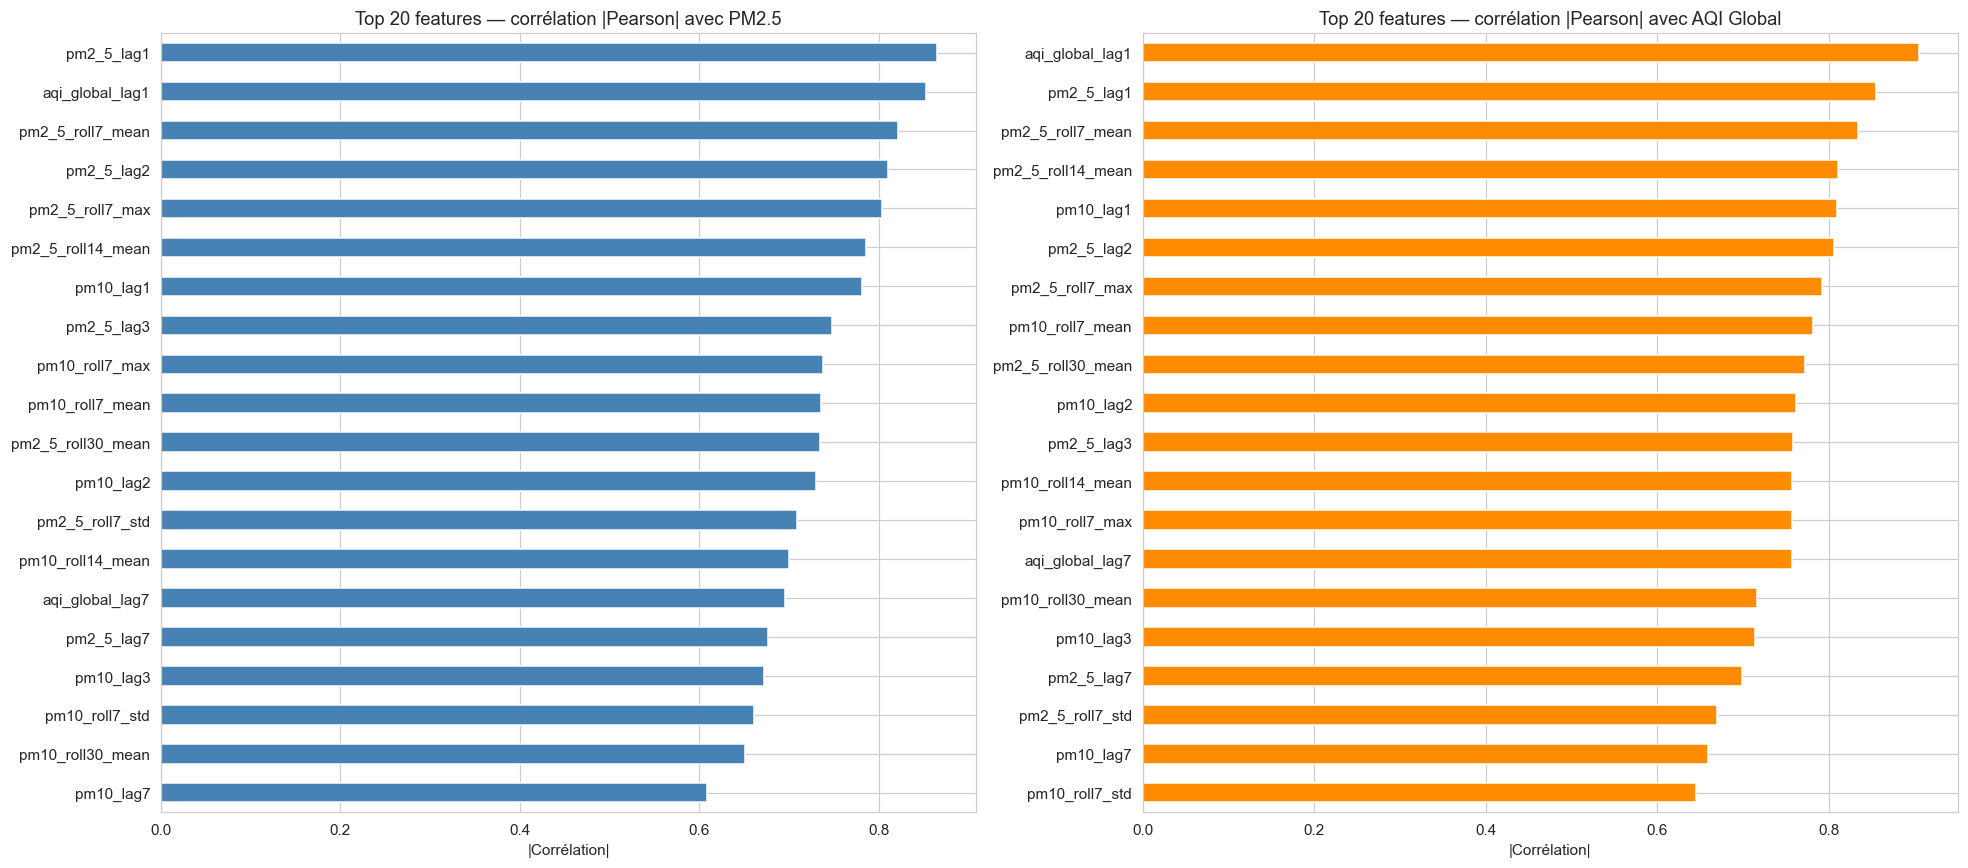

20:34:40 [INFO] 7.1 Corrélations Pearson calculées et sauvegardées


In [35]:
# ── 7.1  Corrélations de Pearson avec les cibles ─────────────────────────────
# Calcul de la matrice de corrélation feature → cibles

corr_data = df[FEATURE_COLS + TARGETS].corr(method='pearson')
corr_targets = corr_data.loc[FEATURE_COLS, TARGETS].abs()

# Top 20 features pour pm2_5 et aqi_global
top20_pm25   = corr_targets['pm2_5'].nlargest(20)
top20_aqi    = corr_targets['aqi_global'].nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top20_pm25.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 features — corrélation |Pearson| avec PM2.5', fontsize=12)
axes[0].set_xlabel('|Corrélation|')

top20_aqi.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 20 features — corrélation |Pearson| avec AQI Global', fontsize=12)
axes[1].set_xlabel('|Corrélation|')

plt.tight_layout()
plt.savefig(DATA / 'fig_corr_top20_features.png', dpi=110, bbox_inches='tight')
plt.show()
log.info('7.1 Corrélations Pearson calculées et sauvegardées')

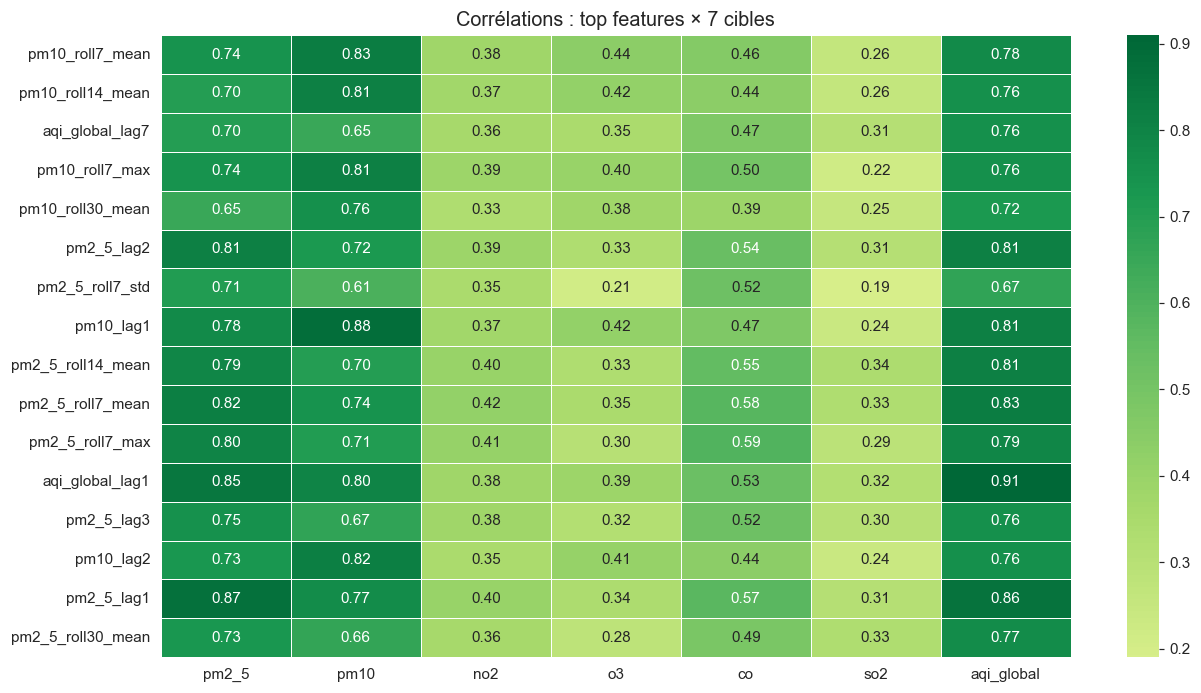

In [36]:
# ── 7.1b  Heatmap corrélations top features × toutes cibles ──────────────────
# Union des top 15 features pour pm2_5 et aqi_global

top_feats = list(set(top20_pm25.nlargest(15).index.tolist() + 
                     top20_aqi.nlargest(15).index.tolist()))

fig, ax = plt.subplots(figsize=(12, max(6, len(top_feats) * 0.4)))
sns.heatmap(
    corr_data.loc[top_feats, TARGETS].round(2),
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Corrélations : top features × 7 cibles', fontsize=13)
plt.tight_layout()
plt.savefig(DATA / 'fig_heatmap_feature_target_corr.png', dpi=110, bbox_inches='tight')
plt.show()

In [37]:
# ── 7.2  Détection multicolinéarité (VIF) ────────────────────────────────────
# Calculer VIF sur un sous-ensemble pour la performance (max 50 features)
# On prend les 50 features les plus corrélées avec pm2_5

log.info('7.2 Calcul VIF (sous-échantillon 50 features)…')

vif_features = corr_targets['pm2_5'].nlargest(50).index.tolist()
vif_data     = df[vif_features].dropna().sample(min(5000, len(df)), random_state=42)

vif_results = []
for i, col in enumerate(vif_features):
    try:
        vif_val = variance_inflation_factor(vif_data.values, i)
        vif_results.append({'feature': col, 'VIF': round(vif_val, 2)})
    except Exception:
        vif_results.append({'feature': col, 'VIF': np.nan})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
high_vif = vif_df[vif_df['VIF'] > 10]

print(f'Features avec VIF > 10 : {len(high_vif)}')
print(high_vif.head(20).to_string(index=False))

# Documenter dans feature_summary (pas de suppression, tree-based OK)
for _, row in high_vif.iterrows():
    if row['feature'] in feature_summary:
        feature_summary[row['feature']]['vif'] = row['VIF']
        feature_summary[row['feature']]['high_multicolinearity'] = True

log.info('VIF calculé. %d features avec VIF>10 (documentées, non supprimées)', len(high_vif))

20:34:41 [INFO] 7.2 Calcul VIF (sous-échantillon 50 features)…
20:34:43 [INFO] VIF calculé. 48 features avec VIF>10 (documentées, non supprimées)


Features avec VIF > 10 : 48
          feature       VIF
   pm10_roll7_max 1360.6200
  pm2_5_roll7_max 1321.1900
  pm10_roll7_mean 1161.1700
 pm2_5_roll7_mean 1142.8800
 pm10_roll14_mean  852.0400
pm2_5_roll14_mean  765.0300
 pm10_roll30_mean  531.2600
pm2_5_roll30_mean  451.0800
         week_cos  434.0400
  day_of_year_cos  432.4200
    co_roll7_mean  389.7900
     co_roll7_max  378.1500
   co_roll14_mean  346.1600
   pm10_roll7_std  267.1000
  pm2_5_roll7_std  263.8900
  no2_roll14_mean  251.3000
       pm2_5_lag3  225.4700
        pm10_lag3  214.3400
   no2_roll7_mean  207.3400
    no2_roll7_max  200.8800


In [38]:
# ── 7.3  Vérification anti-leakage finale ────────────────────────────────────
log.info('7.3 Vérification anti-leakage finale…')

issues = []

# 1) Les cibles ne doivent pas apparaître comme features (sauf via lag/rolling)
for t in TARGETS:
    if t in FEATURE_COLS:
        issues.append(f'LEAKAGE DIRECT : {t} dans FEATURE_COLS')

# 2) Vérifier que les colonnes lag ne sont pas shift(0)
#    Proxy : vérifier que les lag_cols ne sont pas identiques aux originaux
for p in POLLUTANTS:
    lag1_col = f'{p}_lag1'
    corr_val = df[[p, lag1_col]].corr().iloc[0, 1]
    if corr_val > 0.9999:
        issues.append(f'LEAKAGE POTENTIEL : {lag1_col} corrélation parfaite avec {p}')

if issues:
    log.error('PROBLÈMES DÉTECTÉS :\n' + '\n'.join(issues))
    for i in issues:
        print(f'[ERREUR] {i}')
else:
    log.info('Anti-leakage check PASSED : aucun problème détecté')
    print('[OK] Vérification anti-leakage : aucun problème détecté')

# Bilan des features par catégorie
cat_counts = {}
for fname, finfo in feature_summary.items():
    cat = finfo.get('category', 'unknown')
    cat_counts[cat] = cat_counts.get(cat, 0) + 1

print('\n=== Features par catégorie ===')
for cat, cnt in sorted(cat_counts.items()):
    print(f'  {cat:<30} : {cnt}')
print(f'\n  TOTAL : {sum(cat_counts.values())}')

20:34:43 [INFO] 7.3 Vérification anti-leakage finale…
20:34:43 [INFO] Anti-leakage check PASSED : aucun problème détecté


[OK] Vérification anti-leakage : aucun problème détecté

=== Features par catégorie ===
  encoding_dummy                 : 14
  encoding_label                 : 3
  geo_climatic                   : 1
  geo_static                     : 4
  interaction                    : 6
  lag_aqi                        : 2
  lag_meteo                      : 5
  lag_pollutant                  : 36
  meteo_derived                  : 11
  nonlinear                      : 3
  rolling_anomaly                : 6
  rolling_max                    : 6
  rolling_mean                   : 18
  rolling_meteo                  : 4
  rolling_std                    : 6
  target_encoding                : 7
  temporal_calendar              : 6
  temporal_cyclic                : 6
  temporal_season                : 4
  temporal_trend                 : 1

  TOTAL : 149


---
## Section 8 — Sauvegarde et rapport de synthèse

In [39]:
# ── 8.1  Sauvegarde parquet + xlsx ───────────────────────────────────────────
log.info('Section 8 : Sauvegarde…')

OUT_PARQUET = DATA / 'features_engineered.parquet'
OUT_XLSX    = DATA / 'features_engineered.xlsx'
OUT_JSON    = DATA / 'feature_summary.json'

# Parquet — format principal
df.to_parquet(OUT_PARQUET, index=False)
log.info('Sauvegardé → %s (%.1f Mo)', OUT_PARQUET,
         OUT_PARQUET.stat().st_size / 1e6)

# Excel — inspection humaine (1ère feuille)
# Limiter à 100k lignes pour la lisibilité Excel
sample_size = min(100_000, len(df))
df.head(sample_size).to_excel(OUT_XLSX, index=False, sheet_name='features_engineered')
log.info('Sauvegardé → %s (%d lignes)', OUT_XLSX, sample_size)

# JSON — dictionnaire des features
with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(feature_summary, f, ensure_ascii=False, indent=2)
log.info('Sauvegardé → %s (%d features documentées)', OUT_JSON, len(feature_summary))

20:34:43 [INFO] Section 8 : Sauvegarde…
20:34:45 [INFO] Sauvegardé → C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\features_engineered.parquet (46.0 Mo)
20:42:14 [INFO] Sauvegardé → C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\features_engineered.xlsx (87240 lignes)
20:42:15 [INFO] Sauvegardé → C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\feature_summary.json (149 features documentées)


In [50]:
# ── 8.2  Rapport de synthèse ─────────────────────────────────────────────────

n_original = 32  # colonnes du dataset brut
n_features_created = len(feature_summary)

print('=' * 65)
print('  RAPPORT DE SYNTHÈSE — FEATURE ENGINEERING')
print('  Hackathon IndabaX Cameroon 2026')
print('=' * 65)

print(f'\n[DATASET]')
print(f'  Période          : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'  Nb observations  : {len(df):,}')
print(f'  Nb villes        : {df["city_indabax"].nunique()}')
print(f'  Nb régions       : {df["region_indabax"].nunique()}')

print(f'\n[FEATURES]')
print(f'  Colonnes brutes  : {n_original}')
print(f'  Features créées  : {n_features_created}')
print(f'  Total colonnes   : {df.shape[1]}')
print(f'\n  Détail par catégorie :')
for cat, cnt in sorted(cat_counts.items()):
    print(f'    {cat:<32} : {cnt:3d}')

print(f'\n[TOP 5 FEATURES — corrélation |Pearson| avec PM2.5]')
for feat, val in top20_pm25.nlargest(5).items():
    print(f'    {feat:<35} : {val:.4f}')

print(f'\n[TOP 5 FEATURES — corrélation |Pearson| avec AQI Global]')
for feat, val in top20_aqi.nlargest(5).items():
    print(f'    {feat:<35} : {val:.4f}')

print(f'\n[VALEURS MANQUANTES]')
nan_total_final = df[FEATURE_COLS].isnull().sum().sum()
print(f'  NaN total dans les features (après imputation) : {nan_total_final}')
print(f'  NaN total dans les cibles                      : {df[TARGETS].isnull().sum().sum()}')

print(f'\n[FICHIERS PRODUITS]')
for p in [OUT_PARQUET, OUT_XLSX, OUT_JSON]:
    size_mb = pathlib.Path(p).stat().st_size / 1e6
    print(f'  {p.name:<40} : {size_mb:.1f} Mo')

print('\n' + '=' * 65)
print('  Feature Engineering terminé avec succès.')
print('  Prochain notebook : 05_modelisation.ipynb')
print('=' * 65)

  RAPPORT DE SYNTHÈSE — FEATURE ENGINEERING
  Hackathon IndabaX Cameroon 2026

[DATASET]
  Période          : 2020-01-01 → 2025-12-20
  Nb observations  : 87,240
  Nb villes        : 40
  Nb régions       : 10

[FEATURES]
  Colonnes brutes  : 32
  Features créées  : 2
  Total colonnes   : 195

  Détail par catégorie :
    encoding_dummy                   :  14
    encoding_label                   :   3
    geo_climatic                     :   1
    geo_static                       :   4
    interaction                      :   6
    lag_aqi                          :   2
    lag_meteo                        :   5
    lag_pollutant                    :  36
    meteo_derived                    :  11
    nonlinear                        :   3
    rolling_anomaly                  :   6
    rolling_max                      :   6
    rolling_mean                     :  18
    rolling_meteo                    :   4
    rolling_std                      :   6
    target_encoding                

---
## Section 9 — Features avancées (amélioration des modèles)

Features supplémentaires à fort impact physique : proxy de ventilation,
score de risque pollution, séquences sèches, transport régional, rangs percentiles.

In [41]:
# ── 9.0  Charger le dataset feature-engineered (checkpoint existant) ─────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, json, logging, pathlib
from sklearn.preprocessing import LabelEncoder

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger(__name__)

ROOT = pathlib.Path('..').resolve()
DATA = ROOT / 'data'

CKPT_ADV = DATA / 'features_engineered_v2.parquet'

if CKPT_ADV.exists():
    log.info('[SKIP] Chargement checkpoint avance : %s', CKPT_ADV.name)
    df = pd.read_parquet(CKPT_ADV)
else:
    log.info('Chargement features_engineered.parquet...')
    df = pd.read_parquet(DATA / 'features_engineered.parquet')
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values(['city_indabax', 'time']).reset_index(drop=True)

TARGETS      = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2', 'aqi_global']
POLLUTANTS   = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']
feature_summary = {}

log.info('Shape: %s | NaN: %d', df.shape, df.isnull().sum().sum())
print(f'Shape: {df.shape}')

20:42:31 [INFO] [SKIP] Chargement checkpoint avance : features_engineered_v2.parquet
20:42:36 [INFO] Shape: (87240, 194) | NaN: 0


Shape: (87240, 194)


In [42]:
# ── 9.1  Proxy de ventilation (dispersion des polluants) ─────────────────────
# facteur de ventilation = vitesse du vent × ET0 (hauteur couche limite proxy)
# Valeur élevée -> bonne dispersion -> moins de pollution

if 'ventilation_proxy' not in df.columns:
    df['ventilation_proxy'] = df['wind_speed_10m_max'] * df['et0_fao_evapotranspiration']
    feature_summary['ventilation_proxy'] = {
        'category': 'advanced_interaction',
        'description': 'vent × ET0 : proxy dispersion atmospherique des polluants'
    }
    log.info('9.1 ventilation_proxy : OK')
else:
    log.info('[SKIP] ventilation_proxy existe')

20:42:37 [INFO] [SKIP] ventilation_proxy existe


In [43]:
# ── 9.2  Score de risque pollution PM2.5 ─────────────────────────────────────
# Pire configuration : polluant déjà élevé hier + vent calme + harmattan
# Ce score capture les épisodes de pollution intense

if 'pollution_risk_score' not in df.columns:
    df['pollution_risk_score'] = (
        df['pm2_5_lag1'] *
        df['calm_wind_flag'] *
        df['is_harmattan']
    )
    feature_summary['pollution_risk_score'] = {
        'category': 'advanced_interaction',
        'description': 'pm2_5_lag1 x calm_wind x is_harmattan : score risque pollution'
    }
    log.info('9.2 pollution_risk_score : OK')
else:
    log.info('[SKIP] pollution_risk_score existe')

20:42:37 [INFO] [SKIP] pollution_risk_score existe


In [44]:
# ── 9.3  Séquences de jours secs consécutifs ─────────────────────────────────
# Plus une ville reste sans pluie, plus les polluants s'accumulent.
# Cette feature capture la dynamique d'accumulation progressive.

if 'dry_days_streak' not in df.columns:
    def compute_dry_streak(precip_flag_series):
        """Nombre de jours secs consécutifs AVANT le jour courant (shift anti-leakage)."""
        # shift(1) : on ne compte pas le jour courant
        shifted = precip_flag_series.shift(1).fillna(0)
        # Grouper les séquences
        streak = []
        count  = 0
        for v in shifted:
            if v == 0:   # jour sec (pas de pluie)
                count += 1
            else:
                count = 0
            streak.append(count)
        return pd.Series(streak, index=precip_flag_series.index)

    df['dry_days_streak'] = df.groupby('city_indabax')['precip_flag'].transform(
        compute_dry_streak
    )
    feature_summary['dry_days_streak'] = {
        'category': 'advanced_temporal',
        'description': 'Nb jours secs consecutifs avant le jour J (accumulation polluants)'
    }
    log.info('9.3 dry_days_streak : max=%d', df['dry_days_streak'].max())
else:
    log.info('[SKIP] dry_days_streak existe')

20:42:37 [INFO] [SKIP] dry_days_streak existe


In [45]:
# ── 9.4  Transport régional : pollution moyenne régionale décalée ─────────────
# Proxy du transport inter-villes : si les villes voisines sont polluées,
# la pollution peut se propager (vent dominant).

if 'region_pm25_lag1' not in df.columns:
    # Moyenne régionale AVANT calcul du lag -> pas de leakage
    region_daily_mean = (
        df.groupby(['region_indabax', 'time'])['pm2_5']
        .transform('mean')
    )
    df['region_pm25_mean'] = region_daily_mean
    df['region_pm25_lag1'] = df.groupby('city_indabax')['region_pm25_mean']         .transform(lambda s: s.shift(1))

    # Pareil pour pm10 (poussières)
    region_pm10_mean = df.groupby(['region_indabax', 'time'])['pm10'].transform('mean')
    df['region_pm10_mean'] = region_pm10_mean
    df['region_pm10_lag1'] = df.groupby('city_indabax')['region_pm10_mean']         .transform(lambda s: s.shift(1))

    # Imputation NaN (début de série)
    for col in ['region_pm25_lag1', 'region_pm10_lag1']:
        med = df.groupby('city_indabax')[col].transform('median')
        df[col] = df[col].fillna(med).fillna(df[col].median())
        feature_summary[col] = {
            'category': 'advanced_spatial',
            'description': f'Moyenne regionale {col.split("_")[1]} a j-1 (transport inter-villes)'
        }

    # Nettoyer colonnes intermédiaires
    df.drop(columns=['region_pm25_mean', 'region_pm10_mean'], inplace=True)
    log.info('9.4 Transport regional (region_pm25_lag1, region_pm10_lag1) : OK')
else:
    log.info('[SKIP] region_pm25_lag1 existe')

20:42:39 [INFO] 9.4 Transport regional (region_pm25_lag1, region_pm10_lag1) : OK


In [46]:
# ── 9.5  Rangs percentiles (robustesse aux outliers) ─────────────────────────
# Rang de la valeur du polluant dans la distribution historique de la ville.
# Utiliser uniquement le passé (expanding window par groupe).
# La valeur du rang est moins sensible aux valeurs extrêmes.

pct_cols = ['pm2_5', 'pm10', 'co', 'wind_speed_10m_max', 'precipitation_sum']

for col in pct_cols:
    new_col = f'{col}_pct_city'
    if new_col not in df.columns:
        # Expanding rank sur le train pour éviter le leakage global
        df[new_col] = df.groupby('city_indabax')[col].transform(
            lambda s: s.expanding().rank(pct=True)
        )
        feature_summary[new_col] = {
            'category': 'advanced_rank',
            'description': f'Rang percentile de {col} dans l historique de la ville'
        }

log.info('9.5 Percentile ranks : %d features', len(pct_cols))

20:42:41 [INFO] 9.5 Percentile ranks : 5 features


In [47]:
# ── 9.6  Interaction saison × zone + intensité sèche ────────────────────────
if 'harmattan_intensity' not in df.columns:
    # Intensité harmattan = cumul jours secs × score risque (normalisé)
    df['harmattan_intensity'] = df['dry_days_streak'] * df['is_harmattan']

    # Interaction chaleur × ventilation (pire pour O3 quand faible ventilation)
    df['heat_no_wind']  = df['temperature_2m_mean'] * (1 - df['calm_wind_flag'])
    df['o3_risk_score'] = df['sunshine_fraction'] * df['temperature_2m_mean'] * df['is_dry_season']

    new_adv = ['harmattan_intensity', 'heat_no_wind', 'o3_risk_score']
    for c in new_adv:
        feature_summary[c] = {
            'category': 'advanced_interaction',
            'description': f'Feature interaction avancee : {c}'
        }
    log.info('9.6 Interactions avancees : %d features', len(new_adv))
else:
    log.info('[SKIP] harmattan_intensity existe')

20:42:41 [INFO] [SKIP] harmattan_intensity existe


In [48]:
# ── 9.7  Vérification anti-leakage + sauvegarde ──────────────────────────────
# Verifier que les nouvelles features ne contiennent pas les cibles directes
new_feat_cols = [
    'ventilation_proxy', 'pollution_risk_score', 'dry_days_streak',
    'region_pm25_lag1', 'region_pm10_lag1',
    'harmattan_intensity', 'heat_no_wind', 'o3_risk_score',
] + [f'{c}_pct_city' for c in ['pm2_5','pm10','co','wind_speed_10m_max','precipitation_sum']]

new_feat_cols = [c for c in new_feat_cols if c in df.columns]

nan_count = df[new_feat_cols].isnull().sum().sum()
log.info('NaN dans nouvelles features : %d', nan_count)

# Imputation finale
for col in new_feat_cols:
    if df[col].isnull().sum() > 0:
        med = df.groupby('city_indabax')[col].transform('median')
        df[col] = df[col].fillna(med).fillna(df[col].median())

print(f'Nouvelles features ajoutees : {len(new_feat_cols)}')
print(f'Shape final : {df.shape}')
print(f'NaN total   : {df.isnull().sum().sum()}')

20:42:42 [INFO] NaN dans nouvelles features : 0


Nouvelles features ajoutees : 13
Shape final : (87240, 195)
NaN total   : 0


In [49]:
# ── 9.8  Sauvegarde (v2) ─────────────────────────────────────────────────────
import json

OUT_V2   = DATA / 'features_engineered_v2.parquet'
OUT_JSON = DATA / 'feature_summary_v2.json'

df.to_parquet(OUT_V2, index=False)
log.info('Sauvegarde -> %s (%.1f Mo)', OUT_V2.name, OUT_V2.stat().st_size/1e6)

with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(feature_summary, f, ensure_ascii=False, indent=2)

print(f'Dataset v2 : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'Nouvelles features (Section 9) : {len(new_feat_cols)}')
print(f'Total features   : {sum(1 for c in df.columns if c not in ["code","id","time","city_indabax","region_indabax","latitude","longitude","season","eco_zone"]+["pm2_5","pm10","no2","o3","co","so2","aqi_global"] and df[c].dtype != object)}')
print(f'Checkpoint sauvegarde : {OUT_V2}')

20:42:49 [INFO] Sauvegarde -> features_engineered_v2.parquet (51.3 Mo)


Dataset v2 : 87240 lignes x 195 colonnes
Nouvelles features (Section 9) : 13
Total features   : 179
Checkpoint sauvegarde : C:\Users\NICK-TECH\OneDrive\Desktop\HACKATHON-INDABAX-CAMEROON-2026\HACKATHON-INDABAX-CAMEROON-2026\data\features_engineered_v2.parquet
